# Bayesian Marketing Mix Model Challenge

In this notebook, I build a simple Bayesian Marketing Mix Model using weekly revenue and marketing spend data.

The goal is to understand how different marketing channels relate to revenue, while also including a simple carry-over effect using adstock.

In [35]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load the data

I start by loading the dataset and checking the first rows and missing values.

In [36]:
df = pd.read_csv("MMM_test_data.csv")

df["start_of_week"] = pd.to_datetime(df["start_of_week"], format="%d-%m-%y")
df = df.sort_values("start_of_week")

df.head()

,start_of_week,revenue,spend_channel_1,spend_channel_2,spend_channel_3,spend_channel_4,spend_channel_5,spend_channel_6,spend_channel_7
0,2020-08-30,157906.75,2625.48,262.71,12954.12,3609.63,12955.29,12659.12,19379.79
1,2020-09-06,186425.68,2634.01,108.66,8760.28,4560.60,12747.70,12338.18,22473.45
2,2020-09-13,161607.39,2087.08,110.32,7155.42,4362.96,15015.41,10811.15,22596.05
3,2020-09-20,180089.13,1690.70,52.79,15185.22,3883.41,15521.41,12890.22,24728.73
4,2020-09-27,217793.98,1547.30,80.56,18524.05,4043.09,15793.74,12642.55,26515.48


In [37]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum())

Shape: (104, 9)

Missing values:
start_of_week      0
revenue            0
spend_channel_1    0
spend_channel_2    0
spend_channel_3    0
spend_channel_4    0
spend_channel_5    0
spend_channel_6    0
spend_channel_7    0
dtype: int64


The dataset contains weekly revenue and spend for seven marketing channels.  
There are no missing values, so I can continue without additional cleaning.

## Revenue over time

I first plot weekly revenue to understand the general pattern before building the model.


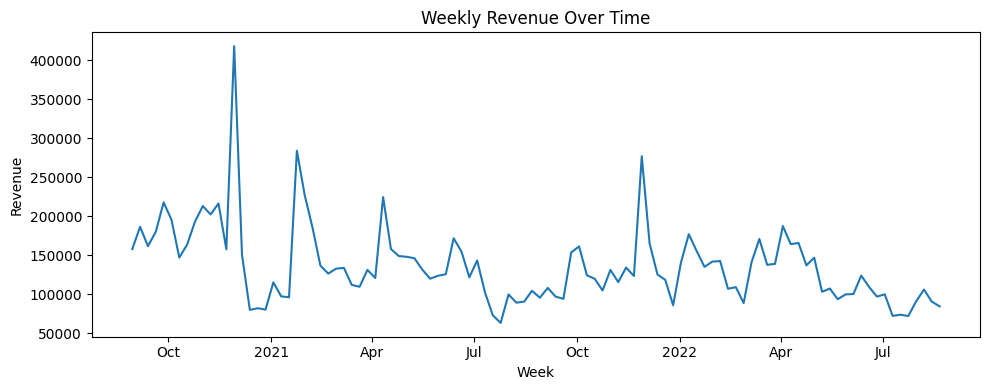

In [38]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df["start_of_week"], df["revenue"])

ax.set_title("Weekly Revenue Over Time")
ax.set_xlabel("Week")
ax.set_ylabel("Revenue")

locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)

ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

fig.tight_layout()
plt.show()

Revenue changes over time and there are some visible spikes.  
This is important because the model only uses media spend, so it may not fully explain sudden jumps caused by other business factors.

## Spend columns

The dataset contains seven paid media spend channels.

In [39]:
spend_cols = [
    "spend_channel_1",
    "spend_channel_2",
    "spend_channel_3",
    "spend_channel_4",
    "spend_channel_5",
    "spend_channel_6",
    "spend_channel_7",
]

## Adstock transformation

Marketing spend does not always affect revenue only in the same week.  
For example, someone may see an ad this week and buy later.

To model this, I use a simple geometric adstock transformation.

I use `alpha = 0.5`, meaning that 50% of the previous carry-over effect remains in the next week.  
I keep this simple because the task says that saturation and more complex adstock shapes are not required for now.

In [40]:
def adstock(values, alpha=0.5):
    result = []
    carryover = 0

    for value in values:
        carryover = value + alpha * carryover
        result.append(carryover)

    return result

In [41]:
adstock_cols = []

for col in spend_cols:
    new_col = col + "_adstock"
    df[new_col] = adstock(df[col], alpha=0.5)
    adstock_cols.append(new_col)

df[["start_of_week", "revenue"] + adstock_cols].head()

,start_of_week,revenue,spend_channel_1_adstock,spend_channel_2_adstock,spend_channel_3_adstock,spend_channel_4_adstock,spend_channel_5_adstock,spend_channel_6_adstock,spend_channel_7_adstock
0,2020-08-30,157906.75,2625.48000,262.710000,12954.1200,3609.630000,12955.290000,12659.120,19379.790000
1,2020-09-06,186425.68,3946.75000,240.015000,15237.3400,6365.415000,19225.345000,18667.740,32163.345000
2,2020-09-13,161607.39,4060.45500,230.327500,14774.0900,7545.667500,24628.082500,20145.020,38677.722500
3,2020-09-20,180089.13,3720.92750,167.953750,22572.2650,7656.243750,27835.451250,22962.730,44067.591250
4,2020-09-27,217793.98,3407.76375,164.536875,29810.1825,7871.211875,29711.465625,24123.915,48549.275625


The new adstock columns will be used as model inputs.  
The original spend columns are still kept because they are needed later for ROI calculation.

## Scaling the data

I scale the adstocked spend columns and revenue before fitting the Bayesian model.

This makes the variables easier for the sampler to work with.  
After prediction, I convert the predicted revenue back to the original revenue scale.

In [42]:
X = df[adstock_cols]
y = df["revenue"]

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaled = x_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(df[["revenue"]]).ravel()

print("X shape:", X_scaled.shape)
print("y shape:", y_scaled.shape)

X shape: (104, 7)
y shape: (104,)


## Bayesian regression model

I use a simple Bayesian linear regression model.

The model predicts scaled revenue using the seven adstocked spend columns.  
Each channel gets its own coefficient.

The model is:

scaled revenue = intercept + channel effects + error

In [43]:
with pm.Model() as model:
    intercept = pm.Normal("intercept", mu=0, sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=1, shape=len(adstock_cols))
    sigma = pm.HalfNormal("sigma", sigma=1)

    mu = intercept + pm.math.dot(X_scaled, beta)

    revenue_obs = pm.Normal(
        "revenue_obs",
        mu=mu,
        sigma=sigma,
        observed=y_scaled
    )

    prior_pred = pm.sample_prior_predictive(draws=500)

    trace = pm.sample(
        draws=1000,
        tune=1000,
        target_accept=0.9,
        chains=4,
        cores=1
    )

    posterior_pred = pm.sample_posterior_predictive(trace)

Sampling: [beta, intercept, revenue_obs, sigma]
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [intercept, beta, sigma]


c:\Users\fares\AppData\Local\Programs\Python\Python312\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 10 seconds.
Sampling: [revenue_obs]


c:\Users\fares\AppData\Local\Programs\Python\Python312\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

The prior predictive samples show what the model expects before seeing the data.  
The posterior samples update the model after observing the data.  
The posterior predictive samples are then used to check how well the model can reproduce revenue.

## Posterior summary

Now I summarize the posterior distributions of the model parameters.

In [44]:
summary = az.summary(trace, var_names=["intercept", "beta", "sigma"])
summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,0,0.084,-0.13,0.14,5280,3022,1.00,0.0012,0.00083
beta[0],-0.138,0.126,-0.34,0.062,3461,2873,1.00,0.0021,0.0015
beta[1],-0.039,0.124,-0.23,0.16,3109,2792,1.00,0.0022,0.0016
beta[2],0.241,0.117,0.054,0.42,4286,3362,1.00,0.0018,0.0012
beta[3],0.015,0.116,-0.17,0.2,3625,2875,1.00,0.0019,0.0014
beta[4],0.2,0.146,-0.037,0.43,3704,2923,1.00,0.0024,0.0017
beta[5],0.445,0.126,0.24,0.64,4011,3039,1.00,0.002,0.0014
beta[6],0.171,0.138,-0.044,0.39,3489,2901,1.00,0.0023,0.0017
sigma,0.839,0.062,0.75,0.95,3888,3278,1.00,0.001,0.00075


In [45]:
beta_summary = az.summary(trace, var_names=["beta"])

beta_summary["channel"] = adstock_cols

beta_summary = beta_summary[
    ["channel", "mean", "sd", "eti89_lb", "eti89_ub", "r_hat"]
]

beta_summary

,channel,mean,sd,eti89_lb,eti89_ub,r_hat
beta[0],spend_channel_1_adstock,-0.138,0.126,-0.34,0.062,1.00
beta[1],spend_channel_2_adstock,-0.039,0.124,-0.23,0.16,1.00
beta[2],spend_channel_3_adstock,0.241,0.117,0.054,0.42,1.00
beta[3],spend_channel_4_adstock,0.015,0.116,-0.17,0.2,1.00
beta[4],spend_channel_5_adstock,0.2,0.146,-0.037,0.43,1.00
beta[5],spend_channel_6_adstock,0.445,0.126,0.24,0.64,1.00
beta[6],spend_channel_7_adstock,0.171,0.138,-0.044,0.39,1.00


The `mean` column gives the average estimated effect for each channel.  
The interval columns show uncertainty.

If an interval includes zero, I interpret the channel effect carefully because the model is not very certain about the direction of the effect.

## Model predictions and performance

I use the posterior predictive samples to calculate predicted revenue.  
Since the model was trained on scaled revenue, I convert the predictions back to the original revenue scale.

In [46]:
pred_scaled = posterior_pred.posterior_predictive["revenue_obs"].mean(
    dim=("chain", "draw")
).values

df["predicted_revenue"] = y_scaler.inverse_transform(
    pred_scaled.reshape(-1, 1)
).ravel()

df[["start_of_week", "revenue", "predicted_revenue"]].head()

,start_of_week,revenue,predicted_revenue
0,2020-08-30,157906.75,99209.982708
1,2020-09-06,186425.68,119890.301043
2,2020-09-13,161607.39,128015.791757
3,2020-09-20,180089.13,147173.863115
4,2020-09-27,217793.98,162558.323897


In [47]:
mae = mean_absolute_error(y, df["predicted_revenue"])
rmse = np.sqrt(mean_squared_error(y, df["predicted_revenue"]))
r2 = r2_score(y, df["predicted_revenue"])

performance = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R²"],
    "value": [mae, rmse, r2]
})

performance

,metric,value
0,MAE,27041.964475
1,RMSE,40393.614653
2,R²,0.361856


MAE and RMSE show the prediction error in revenue units.  
R² shows how much of the revenue variation is explained by the model.

Because this is a simple model using only media spend, I do not expect it to explain every revenue spike perfectly.

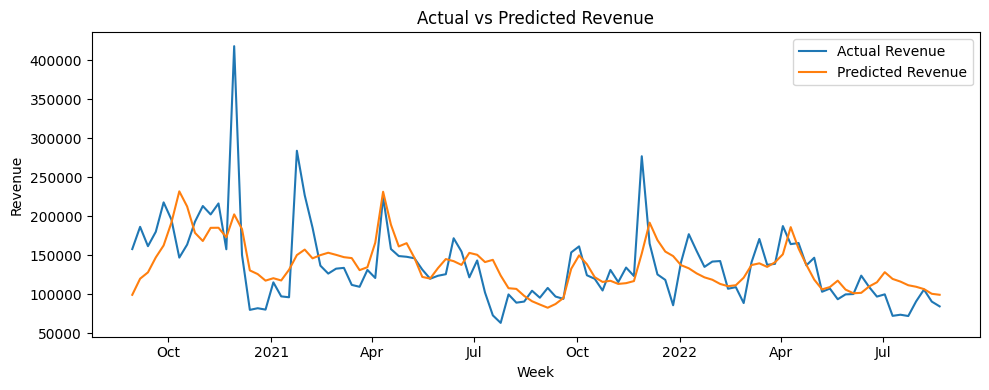

In [48]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df["start_of_week"], df["revenue"], label="Actual Revenue")
ax.plot(df["start_of_week"], df["predicted_revenue"], label="Predicted Revenue")

ax.set_title("Actual vs Predicted Revenue")
ax.set_xlabel("Week")
ax.set_ylabel("Revenue")
ax.legend()

locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)

ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

fig.tight_layout()
plt.show()

The predicted line follows the general revenue movement, but it smooths out some large spikes.  
This suggests that some revenue changes may be driven by factors outside the media spend data, such as promotions, seasonality, pricing, or external events.

## Channel contribution and ROI

To estimate channel contribution, I use a simple counterfactual approach.

For each channel, I compare:

- the model prediction using all channels
- the model prediction when that channel is set to zero

The difference is treated as the estimated contribution of that channel.

ROI is calculated as:

estimated ROI = estimated contribution / actual spend

In [49]:
beta_means = beta_summary["mean"].astype(float).values
intercept_mean = az.summary(trace, var_names=["intercept"])["mean"].astype(float).values[0]

full_mu_scaled = intercept_mean + X_scaled @ beta_means

full_prediction = y_scaler.inverse_transform(
    full_mu_scaled.reshape(-1, 1)
).ravel()

rows = []

for i, spend_col in enumerate(spend_cols):
    adstock_col = adstock_cols[i]

    X_without_channel = X.copy()
    X_without_channel[adstock_col] = 0

    X_without_channel_scaled = x_scaler.transform(X_without_channel)

    prediction_without_channel_scaled = (
        intercept_mean + X_without_channel_scaled @ beta_means
    )

    prediction_without_channel = y_scaler.inverse_transform(
        prediction_without_channel_scaled.reshape(-1, 1)
    ).ravel()

    contribution = full_prediction - prediction_without_channel

    total_contribution = contribution.sum()
    total_spend = df[spend_col].sum()
    roi = total_contribution / total_spend

    rows.append({
        "channel": spend_col,
        "coefficient": beta_means[i],
        "total_spend": total_spend,
        "estimated_contribution": total_contribution,
        "estimated_roi": roi
    })

roi_table = pd.DataFrame(rows)
roi_table = roi_table.sort_values("estimated_roi", ascending=False)

roi_table

,channel,coefficient,total_spend,estimated_contribution,estimated_roi
5,spend_channel_6,0.445,526624.70,2.123830e+06,4.032909
2,spend_channel_3,0.241,2028746.51,3.869269e+06,1.907221
4,spend_channel_5,0.200,891863.59,1.407708e+06,1.578390
6,spend_channel_7,0.171,2880942.21,2.373035e+06,0.823701
3,spend_channel_4,0.015,719174.22,2.205436e+05,0.306662
0,spend_channel_1,-0.138,129542.90,-8.380072e+05,-6.468955
1,spend_channel_2,-0.039,35738.66,-2.537926e+05,-7.101346


The ROI table ranks channels by estimated ROI.

A higher ROI means that the model estimates more revenue contribution per unit of actual spend.

These values are model-based estimates, so I would interpret them carefully rather than treating them as exact causal truth.

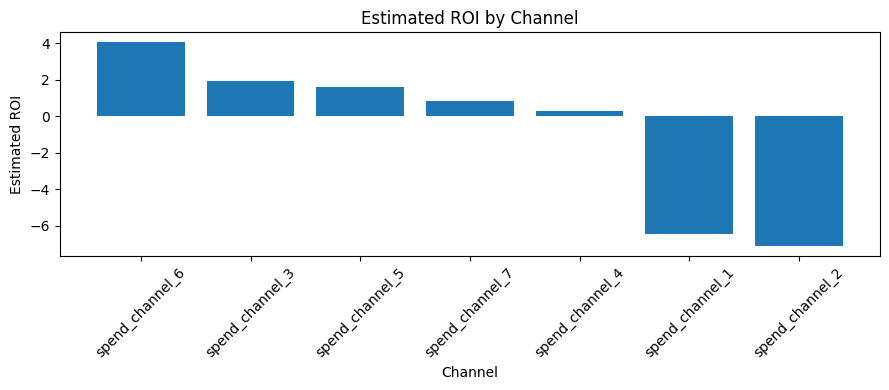

In [50]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(roi_table["channel"], roi_table["estimated_roi"])

ax.set_title("Estimated ROI by Channel")
ax.set_xlabel("Channel")
ax.set_ylabel("Estimated ROI")

plt.xticks(rotation=45)

fig.tight_layout()
plt.show()

In [51]:
best_channel = roi_table.iloc[0]["channel"]
best_roi = roi_table.iloc[0]["estimated_roi"]

print("Best ROI channel:", best_channel)
print("Estimated ROI:", round(best_roi, 3))

Best ROI channel: spend_channel_6
Estimated ROI: 4.033


## Limitations

This is a simple first version of a Bayesian MMM.

Main limitations:

- I used a fixed adstock value of alpha = 0.5 instead of estimating it from the data.
- The model assumes a linear relationship between adstocked spend and revenue.
- I did not include saturation or diminishing returns.
- I did not include seasonality, trend, promotions, pricing, or external events.
- Some large revenue spikes are not fully explained by media spend alone.
- ROI estimates are model-based estimates and should not be interpreted as exact causal truth.

## Conclusion

This model gives a first estimate of how the seven paid media channels relate to revenue.

The actual-vs-predicted plot shows that the model captures the general revenue movement, but it does not fully explain large spikes.  
This suggests that other business factors may also be important.

The ROI table gives a ranking of channels based on estimated contribution divided by actual spend.  
I would use these results as a starting point for further analysis, not as final budget allocation decisions.


## Answers to the challenge questions

**How did I model spend carry-over?**  
I used a geometric adstock transformation with alpha = 0.5.

**What priors did I use?**  
I used Normal priors for the intercept and channel coefficients, and a HalfNormal prior for the error term.

**How are results based on prior sampling vs posterior sampling?**  
Prior predictive sampling shows what the model expects before seeing the data. Posterior sampling updates the model parameters after observing the data.

**How good is the model?**  
I evaluated the model with MAE, RMSE, R², and an actual-vs-predicted revenue plot.

**What are the main channel effects?**  
The posterior coefficient table shows the estimated effect and uncertainty for each channel.

**Can ROI estimates be derived?**  
Yes. I estimated contribution using a counterfactual approach and calculated ROI as contribution divided by actual spend.

**What is the best channel in terms of ROI?**  
The best channel is the first channel in the ROI table.